# **BAIS330 Project** 


### Section 1: Project Description
___
This project analyzes global cybersecurity threat data to better understand how factors such as attack type, target industry, number of affected users, and incident response time impact financial loss. Using Python and pandas, the dataset was explored, processed, and visualized to identify patterns and trends that influence the severity and cost of cyberattacks.

#### Analysis Focus
- Section 4: Which attack types result in the highest financial losses, and which affect the greatest number of users? Is there a relationship between financial impact and user impact? <br><br>
- Section 5: What is the risk accross the different attack vectors?  <br><br>
- Section 6: Which industries experienced the highest number of attacks, and which attack sources were primarily responsible for those attacks within each industry? <br><br>
- Section 7: What countries face the most threats? What countries have the best Mean MTTR (Mean Time To Respond)?

<br><br>
For my project I used the Global Cybersecurity Threats dataset from Kaggle. 
https://www.kaggle.com/datasets/atharvasoundankar/global-cybersecurity-threats-2015-20 




### Section 2: Import Libraries and Data
___

In [1]:
# Import Libraries 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Mount Drive 
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# File 
# file_path = '/content/drive/MyDrive/BAIS330_DATA/Cybersecurity_Threats_Data_FP330.csv' 

file_path = '/content/drive/MyDrive/330_project/330_Rhea_Zach_Project.csv' # Path for presentation
df = pd.read_csv(file_path)
print(df.head(n=10)) 

   Country  Year        Attack Type     Target Industry  \
0    China  2019           Phishing           Education   
1    China  2019         Ransomware              Retail   
2    India  2017  Man-in-the-Middle                  IT   
3       UK  2024         Ransomware  Telecommunications   
4  Germany  2018  Man-in-the-Middle                  IT   
5  Germany  2017  Man-in-the-Middle              Retail   
6  Germany  2016               DDoS  Telecommunications   
7   France  2018      SQL Injection          Government   
8    India  2016  Man-in-the-Middle             Banking   
9       UK  2023               DDoS          Healthcare   

   Financial Loss (in Million $)  Number of Affected Users Attack Source  \
0                          80.53                    773169  Hacker Group   
1                          62.19                    295961  Hacker Group   
2                          38.65                    605895  Hacker Group   
3                          41.44              

### Section 2 (Part 2): Install/Setup API 
___

In [4]:
!pip install openai

In [ ]:
# Load OpenAI API Key 
import os
from openai import OpenAI
api_key = None
try:
    from google.colab import userdata
    api_key = userdata.get("OPENAI_API_KEY")
except Exception:
    pass
#TEMPORARY API KEY
api_key = " "
if not api_key:
    raise ValueError("OpenAI API key not found. Add OPENAI_API_KEY in Colab Secrets or paste it in this cell.")
os.environ["OPENAI_API_KEY"] = api_key
client = OpenAI()
print("API key loaded.")



API key loaded.


### Section 3: Examine The Data 
___



In [6]:
# Examine the number of rows and cols
df.shape

(3000, 10)

In [7]:
# Columns
print(df.columns)

Index(['Country', 'Year', 'Attack Type', 'Target Industry',
       'Financial Loss (in Million $)', 'Number of Affected Users',
       'Attack Source', 'Security Vulnerability Type',
       'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'],
      dtype='object')


In [8]:
# Rename Columns
df = df.rename(columns={
    "Financial Loss (in Million $)": "Loss $M",
    "Number of Affected Users": "Users Affected",
    "Security Vulnerability Type": "Vulnerability",
    "Incident Resolution Time (in Hours)": "TTR (Hours)",
    "Defense Mechanism Used": "Defense Mechanism",  # FIXED
    "Attack Type": "Attack"
})

In [9]:
# Re-print Columns
print(df.columns)

Index(['Country', 'Year', 'Attack', 'Target Industry', 'Loss $M',
       'Users Affected', 'Attack Source', 'Vulnerability', 'Defense Mechanism',
       'TTR (Hours)'],
      dtype='object')


In [10]:
# Check for  Missing Values 
df.isnull().sum().sum()

np.int64(0)

In [11]:
# Check for Duplicate Data 
df.duplicated().sum()

np.int64(0)

Thankfully there are no duplicate or null values so we will not have to clean the data. 

### Section 4: Which attack types result in the highest financial losses, and which affect the greatest number of users? Is there a relationship between financial impact and user impact?
___

In [12]:
# Total Financial Losses Vs Total Users Affected

# Group By Attack Type And Find The Financial Loss for Each 
attack_loss_total = df.groupby("Attack")["Loss $M"].sum().round(2)

# Summary Report 
print(36 * "-")
print("Total Financial Loss by Attack Type:") # Title 
print(36 * "-")
print(f"{"Attack":<21}Total Financial Loss") # Column Names

# All Category Totals > 1B so set everything to Billions 
attack_loss_billions = attack_loss_total / 1000
for attack, value in attack_loss_billions.items():
    # Print summary of financial losses
    print(f"{attack:<20} ${value:>8.2f}B")

print("\n\n") ############################################################

# Group By Attack Type And Find The Users Affected for Each 
attack_users_total = df.groupby("Attack")["Users Affected"].sum().round(2)

# Summary Report 
print(36 * "-")
print("Total Users Affected by Attack Type:") # Title 
print(36 * "-")
print(f"{"Attack":<21}Total Users Affected") # Column Names

# Loop Through Results 
for attack, total in attack_users_total.items():
    print(f"{attack:<20} {total:>20,.0f}")


------------------------------------
Total Financial Loss by Attack Type:
------------------------------------
Attack               Total Financial Loss
DDoS                 $   27.63B
Malware              $   23.97B
Man-in-the-Middle    $   23.55B
Phishing             $   26.69B
Ransomware           $   24.48B
SQL Injection        $   25.16B



------------------------------------
Total Users Affected by Attack Type:
------------------------------------
Attack               Total Users Affected
DDoS                          265,201,265
Malware                       246,758,413
Man-in-the-Middle             238,709,523
Phishing                      257,717,975
Ransomware                    247,892,907
SQL Injection                 257,772,326


In [13]:
# Average Finanical Losses Vs Average Users Affected

# Function for average financial losses by different attack types 
def avg_dollar_for_attacks(df, *attack_types): # Using Args*
    print(50 * '-')
    print("Average Financial Loss by Attack Type") # Title 
    print(50 * '-')
    print(f"{'Attack Type':<27} {'Loss':>10}") # Column Names
    
    # Initialize values For finding highest value
    highestdollar_attack = None
    highestdollar_avg = 0
    
    for attack in attack_types:
        avg = df[df["Attack"] == attack]["Loss $M"].mean()
        print(f"{attack:<20} {avg:>15,.0f}")
        
        # Track which has highest # of users affected
        if avg > highestdollar_avg:
            highestdollar_avg = avg
            highestdollar_attack = attack
        
    # Final output at bottom
    print(50 * '-')
    print(f"{highestdollar_attack} has the highest average amount of financial loss,")
    print(f"with approximately {highestdollar_avg:,.0f}B  dollars.")
    
# Run Function        
avg_dollar_for_attacks(df, "DDoS", "Phishing", "Malware", "SQL Injection", "Man-in-the-Middle")


print("\n\n") ############################################################


# Function for average number of users affected by different attack types 
def avg_users_for_attacks(df, *attack_types):
    print(50 * '-')
    print("Average Users Affected by Attack Type")
    print(50 * '-')
    print(f"{'Attack Type':<27} {'Users Affected':>15}")
    
    highestuser_attack = None
    highestuser_avg = 0
    
    for attack in attack_types:
        avg2 = df[df["Attack"] == attack]["Users Affected"].mean()  # DEFINE avg2
        
        print(f"{attack:<20} {avg2:>15,.0f}")
        
        # Track highest
        if avg2 > highestuser_avg:
            highestuser_avg = avg2
            highestuser_attack = attack
    
    print(50 * '-')
    print(f"{highestuser_attack} has the highest average number of users affected,")
    print(f"with approximately {highestuser_avg:,.0f} users per attack.")
    
avg_users_for_attacks(df, "DDoS", "Phishing", "Malware", "SQL Injection", "Man-in-the-Middle")

--------------------------------------------------
Average Financial Loss by Attack Type
--------------------------------------------------
Attack Type                       Loss
DDoS                              52
Phishing                          50
Malware                           49
SQL Injection                     50
Man-in-the-Middle                 51
--------------------------------------------------
DDoS has the highest average amount of financial loss,
with approximately 52B  dollars.



--------------------------------------------------
Average Users Affected by Attack Type
--------------------------------------------------
Attack Type                  Users Affected
DDoS                         499,437
Phishing                     487,180
Malware                      508,780
SQL Injection                512,470
Man-in-the-Middle            520,064
--------------------------------------------------
Man-in-the-Middle has the highest average number of users affected,
with a

In [14]:
# Create Data For Visualizations

# Get attack types
attack_types = df["Attack"].unique()

# Create dictionary 
data = {}

# Convert to numpy arrays 
for attack in attack_types:
    loss_arr = df[df["Attack"] == attack]["Loss $M"].to_numpy()
    user_arr = df[df["Attack"] == attack]["Users Affected"].to_numpy()
    
    # Scale Data
    data[attack] = {
        "loss": loss_arr,
        "users": user_arr
    }

# Empty Dictionaries for each catagory     
summary_loss = {}
summary_users = {}

for attack, values in data.items():
    
    # Loss
    arr = values["loss"]
    summary_loss[attack] = [
        np.sum(arr),
        np.mean(arr),
        np.max(arr),
        np.min(arr)
    ]
    
    # Users
    arr = values["users"]
    summary_users[attack] = [
        np.sum(arr),
        np.mean(arr),
        np.max(arr),
        np.min(arr)
    ]

# Dictionary to DataFrame (2 separate dataframes)
loss_df = pd.DataFrame(summary_loss, index=["Total", "Average", "Max", "Min"])
users_df = pd.DataFrame(summary_users,index=["Total", "Average", "Max", "Min"])

# Format loss as money
loss_df = loss_df * 1000000 # Convert to true dollar amount from millions 
loss_df = loss_df.map(lambda x: f"${x:,.0f}")
# Format users with commas
users_df = users_df.map(lambda x: f"{x:,.0f}")

#Print Summary
print("Financial Loss Report")
print(200 * '-')
print(loss_df.to_string()) # display the DataFrame as a clean formatted text table
print("\n")
print("Customers Affected Report")
print(200 * '-')
print(users_df.to_string())
print()
print()





Financial Loss Report
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                Phishing       Ransomware Man-in-the-Middle             DDoS    SQL Injection          Malware
Total    $26,693,290,000  $24,479,320,000   $23,550,870,000  $27,630,920,000  $25,156,560,000  $23,967,950,000
Average      $50,459,905      $49,653,793       $51,309,085      $52,035,631      $50,013,042      $49,418,454
Max          $99,980,000      $99,900,000       $99,710,000      $99,990,000      $99,990,000      $99,720,000
Min             $920,000       $1,420,000          $540,000         $500,000         $720,000         $540,000


Customers Affected Report
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

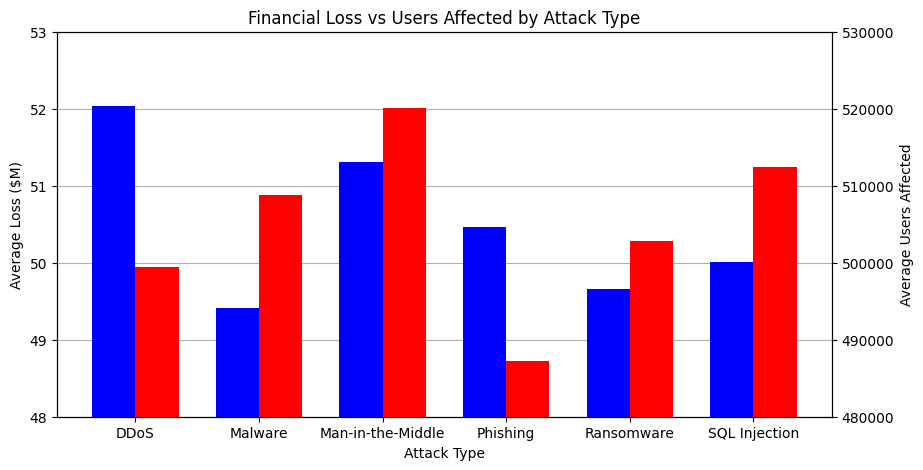

In [15]:
# Data vizualization comparing users affected and financial losees (Line Chart)
avg_loss = df.groupby("Attack")["Loss $M"].mean() #Find Averages once again since can't plot string value
avg_users = df.groupby("Attack")["Users Affected"].mean()

x = np.arange(len(avg_loss.index))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 5))

# $ Loss Axis (Left)
bars1 = ax1.bar(x - width/2, avg_loss.values, width=width, label='Loss ($M)', color='blue')
ax1.set_ylabel('Average Loss ($M)')
ax1.set_xlabel('Attack Type')

# Zoom $ Loss Axis to show how much of a difference there is --> (Lowest Value Shown, Highest Value Shown) 
ax1.set_ylim(48, 53) # Loss ($M)


# User axis (Right)
ax2 = ax1.twinx() # Creates a twin axis to accomodate for the scaling issues when comparing this data
bars2 = ax2.bar(x + width/2, avg_users.values, width=width, label='Users', color='red')
ax2.set_ylabel('Average Users Affected')

# Zoom User Axis
ax2.set_ylim(480000, 530000) # Users

# X labels
plt.xticks(x, avg_loss.index, rotation=45)

# Title
plt.title('Financial Loss vs Users Affected by Attack Type')

# Combine legends
bars = bars1 + bars2
labels = [b.get_label() for b in bars]

# plt.grid(axis='y', zorder=0) <-- This didn't work because of twin axis
ax1.set_axisbelow(True) # Grid Behind bars 
ax1.grid(axis='y')

plt.show()

In [16]:
# Prompt
summary_prompt1 = f"""
You are analyzing cybersecurity data.

Average amount of finanical Loss grouped by attack type:
{avg_loss.to_string()}

Average number of users affected grouped by attack type:
{avg_users.to_string()}

Answer clearly:
Write a clean summary:

Answer questions 1-3 in bulletpoint form)()
1. Which attack types result in the highest financial losses?
2. which affect the greatest number of users?
3. Give any additional useful metrics in the form of bullet points?

4. One sentence conclusion answering "Is there a relationship between financial impact and user impact"?
"""

In [17]:
# Print Response 
response1 = client.responses.create(
    model="gpt-4o-mini",
    input=summary_prompt1,
)

print(response1.output_text)

### Summary of Cybersecurity Data Analysis

1. **Attack Types with Highest Financial Losses:**
   - DDoS: $52.04
   - Man-in-the-Middle: $51.31
   - Phishing: $50.46

2. **Attack Types Affecting the Greatest Number of Users:**
   - Man-in-the-Middle: 520,064 users
   - SQL Injection: 512,470 users
   - Malware: 508,780 users

3. **Additional Useful Metrics:**
   - Ransomware has an average financial loss of $49.65 and affects 502,825 users.
   - SQL Injection has an average financial loss of $50.01 and affects 512,470 users.
   - Phishing has an average financial loss of $50.46 and affects 487,180 users.

4. **Conclusion:**
   - There appears to be a positive correlation between financial impact and user impact, with higher losses often associated with a greater number of affected users.


### Section 5: What is the risk accross the different attack vectors? 
___
 Risk = Probability x Impact

In [18]:
# Tests to find range for risk classification
'''
test_count = (df["Attack"] == "Ransomware").sum()
print(test_count)
test_prob = test_count / len(df)
print(test_prob)
test_loss = df[df["Attack"] == "Ransomware"]["Loss $M"].mean()
test_score = (test_loss * test_prob) * 100
print()
print()
print("Test Score: ", round(test_score))
'''
# Risks
# DDoS --> 920
# Malware --> 790
# MITM/On Path --> 780
# Phishing 889
# SQLI --> 839
# Ransomware --> 816

# Risk Levels 
# Low Risk <= 800
# Medium Risk <= 850
# High Risk <= 875
# Critical Risk > 900 

'\ntest_count = (df["Attack"] == "Ransomware").sum()\nprint(test_count)\ntest_prob = test_count / len(df)\nprint(test_prob)\ntest_loss = df[df["Attack"] == "Ransomware"]["Loss $M"].mean()\ntest_score = (test_loss * test_prob) * 100\nprint()\nprint()\nprint("Test Score: ", round(test_score))\n'

In [19]:
# Create Function To Analyze Risk Across Different Attacks
def calculate_risk(df, attack_type):
    
    
    # Calculate Probablilty --> Count / Total # of Attacks
    count = (df["Attack"] == attack_type).sum()
    probability = count / len(df) #df has 3000 records
    
    # Calculate Average Loss in Millions
    avg_loss = df[df["Attack"] == attack_type]["Loss $M"].mean()

    # Risk Score 
    risk_score = (probability * avg_loss) * 100
    
    # Assign Risk Classifications 
    if risk_score <= 800:
        risk_rating = "Low Risk"
    elif risk_score <= 850:
        risk_rating = "Medium Risk"
    elif risk_score <= 900:
        risk_rating = "High Risk"
    elif risk_score > 900:
        risk_rating = "Critical Risk"


    print(f"{attack_type:<20} {risk_rating:>8}")
    
    return(risk_rating)

# Header
print(40 * '-')
print(f"{'Attack Type':<20} {'Risk Rating':>8}") 
print(40 * '-')

calculate_risk(df, "DDoS")
calculate_risk(df, "Malware") 
calculate_risk(df, "Man-in-the-Middle") 
calculate_risk(df, "Phishing") 
calculate_risk(df, "Ransomware")  
calculate_risk(df, "SQL Injection")  

----------------------------------------
Attack Type          Risk Rating
----------------------------------------
DDoS                 Critical Risk
Malware              Low Risk
Man-in-the-Middle    Low Risk
Phishing             High Risk
Ransomware           Medium Risk
SQL Injection        Medium Risk


'Medium Risk'

DDoS                 Critical Risk
Malware              Low Risk
Man-in-the-Middle    Low Risk
Phishing             High Risk
Ransomware           Medium Risk
SQL Injection        Medium Risk


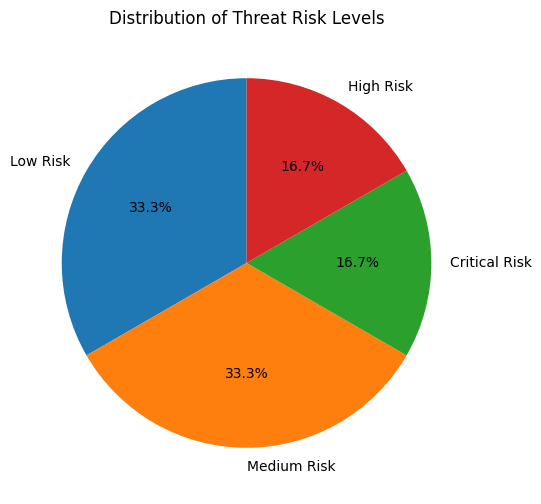

In [20]:
# Pie Chart 
attack_types = ["DDoS", "Malware", "Man-in-the-Middle", "Phishing", "Ransomware", "SQL Injection"]

risk_results = []

# Run previous funtion and store results for visualization
for attack in attack_types:
    risk = calculate_risk(df, attack)
    risk_results.append(risk)

# Count each category 
risk_counts = pd.Series(risk_results).value_counts() # Use Series for Pie chart values  

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(risk_counts.values,
        labels=risk_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribution of Threat Risk Levels")

plt.show()

In [21]:
# Data for Summary
# Count number of each attack type 
attack_counts = df["Attack"].value_counts()

# Generate risk rating for each attack type
attack_risk_map = {}

for attack in attack_counts.index:
    attack_risk_map[attack] = calculate_risk(df, attack)

# Convert to DataFrame
risk_df = attack_counts.reset_index()
risk_df.columns = ["Attack", "Count"]

# Store risk ratings to each attack type
risk_df["Risk Level"] = risk_df["Attack"].map(attack_risk_map)

risk_counts = risk_df.groupby("Risk Level")["Count"].sum()

DDoS                 Critical Risk
Phishing             High Risk
SQL Injection        Medium Risk
Ransomware           Medium Risk
Malware              Low Risk
Man-in-the-Middle    Low Risk


In [22]:
# Prompt
summary_prompt2 = f"""
You are analyzing cybersecurity risk data.

DataFrame Size 
{len(df)}

Attack  Breakdown
{risk_df.to_string(index=False)}

Count of each risk level:
{risk_counts.to_string()}

Answer clearly:

Answer 1-3 in bulletpoint form and be concise.
1. What attack types pose the highest risk
2. What attack types are the lowest risk
3. What risk level is most common (# of occurances)
4. what risk level is least common (# of occurances)

5. sentence summary, each sentence should be a bulletpoint. Label the Section "Quick Summary"

"""

In [23]:
# Print Response 
response2 = client.responses.create(
    model="gpt-4o-mini",
    input=summary_prompt2,
)

print(response2.output_text)

### Key Insights

1. **Attack types posing the highest risk:**
   - DDoS (Critical Risk)
   - Phishing (High Risk)

2. **Attack types posing the lowest risk:**
   - Malware (Low Risk)
   - Man-in-the-Middle (Low Risk)

3. **Most common risk level:**
   - Medium Risk (996 occurrences)

4. **Least common risk level:**
   - Critical Risk (531 occurrences)

### Quick Summary
- The highest risk attacks are DDoS and Phishing.
- The lowest risk attacks are Malware and Man-in-the-Middle.
- Medium Risk is the most common risk level in the dataset.
- Critical Risk is the least common risk level.


### Section 6: Which industries experienced the highest number of attacks, and which attack sources were primarily responsible for those attacks within each industry?
___

Resource for creating heatmap with matplotlib / numpy instead of snsplot: https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html 

In [24]:
# Create table showing industries and attack sources within them
industry_source = df.groupby(["Target Industry", "Attack Source"]).size().unstack() # Unstack to make each attack source a column  

# Print new table
print("Attack Distribution by Industry and Source")
print("-" * 60)

print(industry_source.to_string())


Attack Distribution by Industry and Source
------------------------------------------------------------
Attack Source       Hacker Group  Insider  Nation-state  Unknown
Target Industry                                                 
Banking                       94      126           122      103
Education                     80      126           125       88
Government                   101       95           101      106
Healthcare                   104      103           101      121
IT                           111      108           110      149
Retail                        99       91           125      108
Telecommunications            97      103           110       93


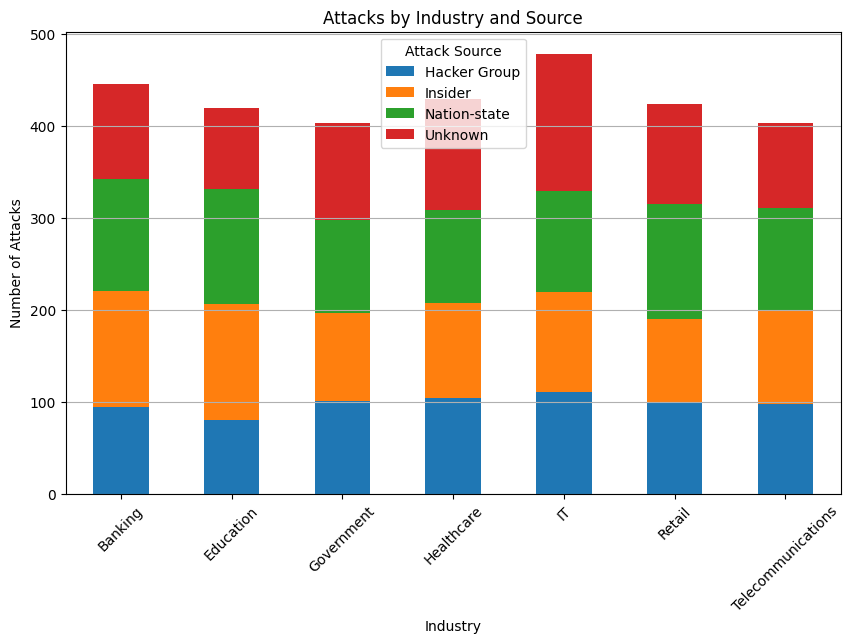

In [25]:
# Create a Stacked Bar Chart 
industry_source.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Attacks by Industry and Source")
plt.xlabel("Industry")
plt.ylabel("Number of Attacks")
plt.xticks(rotation=45)

# Legend 
plt.legend(title="Attack Source")
# Grid
plt.grid(axis='y')

plt.show()

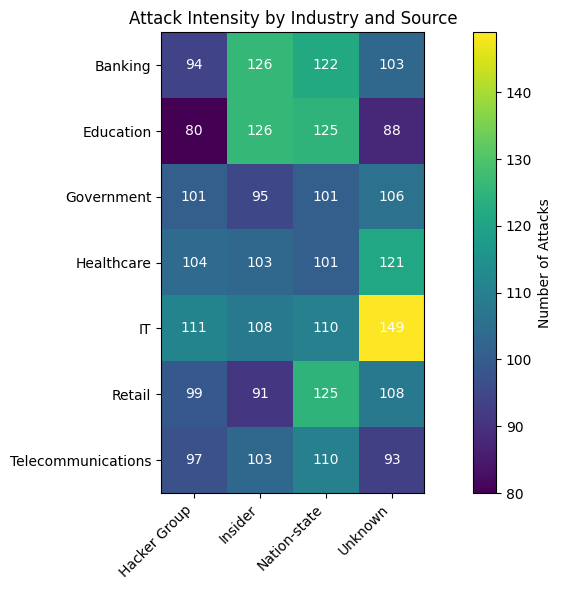

In [26]:
# Convert DataFrame to numpy 
data = industry_source.to_numpy()

# Convert to lists 
industries = industry_source.index.tolist() # Rows 
sources = industry_source.columns.tolist() # Columns

fig, ax = plt.subplots(figsize=(10,6))

# Heatmap
im = ax.imshow(data)

# X and Y, Use Lists 
ax.set_xticks(range(len(sources)), labels=sources, rotation=45, ha="right") 
ax.set_yticks(range(len(industries)), labels=industries)

# Loop over data dimensions <-- Numbers in each box
for i in range(len(industries)):
    for j in range(len(sources)):
        ax.text(j, i, int(data[i, j]),
                ha="center", va="center", color="white")

# Title
ax.set_title("Attack Intensity by Industry and Source")

# Color bar 
plt.colorbar(im, label="Number of Attacks")

plt.tight_layout()
plt.show()

In [27]:
# Prompt
summary_prompt3 = f"""
You are analyzing cybersecurity data.

Attack Distribution by Industry 
{industry_source.to_string()}

Answer clearly:
Write a clean summary:


- Provide adequate spacing/formatting to make the response easier to read

Answer 1-5 in bulletpoint form and be concise. 
(Give tangible metrics in parenthesis (Occurances__))
1. What industry recieved the most attacks? What attack source was responsible for the majority of these? 
2. What attack sources were responsible for the most attacks overall?
3. What industry recieved the least attacks? 
4. What attack sources were the most uncommon?
5. What industry did nation-state attackers target the most?


"""

In [28]:
# Print Response 
response3 = client.responses.create(
    model="gpt-4o-mini",
    input=summary_prompt3,
)

print(response3.output_text)

### Cybersecurity Attack Analysis Summary

1. **Most Attacked Industry**:  
   - **Banking** received the most attacks with a total of **445 occurrences**.  
   - Majority from **Insider** sources (126 occurrences).

2. **Most Common Attack Sources**:  
   - **Insider** attacks totaled **819 occurrences** across all industries.  
   - Followed by **Hacker Group** (732 occurrences).

3. **Least Attacked Industry**:  
   - **Telecommunications** received the least attacks, totaling **403 occurrences**.

4. **Most Uncommon Attack Sources**:  
   - **Unknown** sources had the least occurrences with **780 total attacks across all industries**. 

5. **Industry Most Targeted by Nation-state**:  
   - **Banking** was the primary target for **Nation-state** attackers, with **122 occurrences**.


### Section 7: What countries face the most threats? What countries have the best Mean MTTR (Mean Time To Repair)?
___

Resource for boxplots on Matplotlib: https://stackoverflow.com/questions/44119653/creating-a-boxplot-with-matplotlib 

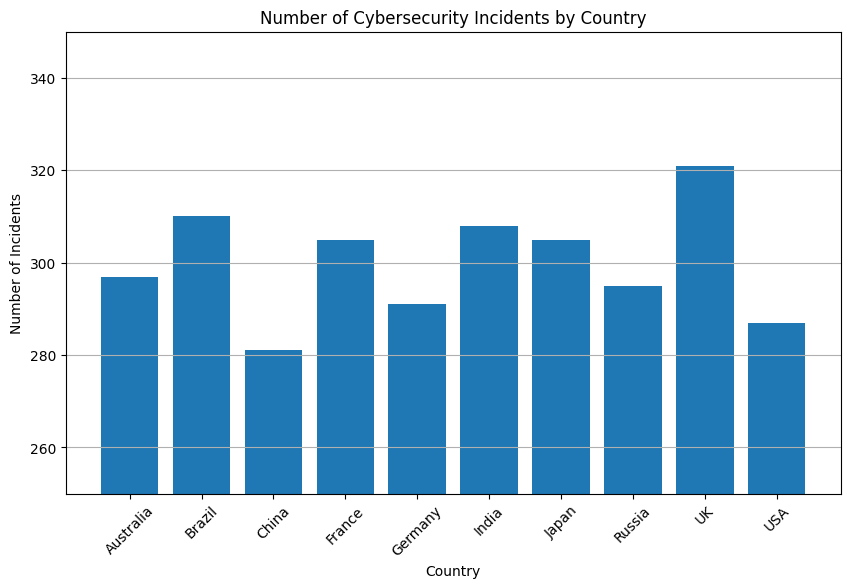

In [29]:
# Group by country to find number of cybersecurity attacks 
num_attacks = df.groupby("Country").size() # Number of records per country in dataset

# Create Bar Chart
plt.figure(figsize=(10,6))

plt.bar(num_attacks.index, num_attacks.values)

plt.title("Number of Cybersecurity Incidents by Country")
plt.xlabel("Country")
plt.ylabel("Number of Incidents")

# Set y axis range 
plt.ylim(250, 350)

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

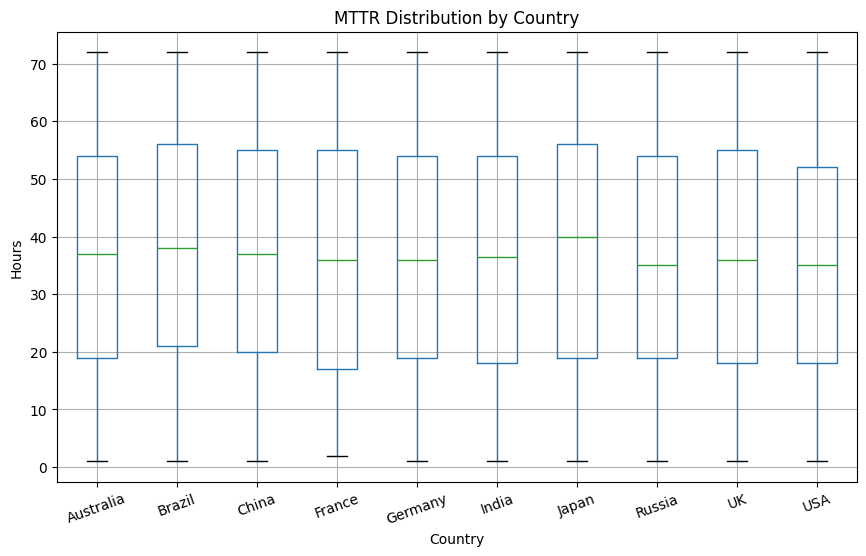

In [30]:
# Create a boxplot 
df.boxplot(column="TTR (Hours)", by="Country", rot = 20, figsize=(10,6))

plt.title("MTTR Distribution by Country")
plt.suptitle("")
plt.ylabel("Hours")
plt.show()

In [31]:
#Create data for summary
# Incidents per country
country_attacks = df.groupby("Country").size()

# Average MTTR per country
country_mttr = df.groupby("Country")["TTR (Hours)"].mean()

In [32]:
# Prompt
summary_prompt4 = f"""
You are analyzing cybersecurity data.

Number of Incidents by Country:
{country_attacks.to_string()}

Average MTTR (Hours) by Country:
{country_mttr.round(2).to_string()}

Answer clearly:
Write a clean summary:
- Use bullet points and make it clear and concise

1. Which 3 countries experience the most cybersecurity incidents? State the amount of incidents
2. Which 3 countries have the best (lowest) MTTR?
3. Which 3 counteis have the worst (highest) MTTR?
4. Write a short paragraph answering "what insight can you draw about the relationship between incident volume and response time"? 

"""

In [33]:
# Print Response 
response4 = client.responses.create(
    model="gpt-4o-mini",
    input=summary_prompt4,
)

print(response4.output_text)

### Summary of Cybersecurity Data

**1. Countries with the Most Cybersecurity Incidents:**
   - **UK:** 321 incidents
   - **Brazil:** 310 incidents
   - **India:** 308 incidents

**2. Countries with the Best (Lowest) MTTR:**
   - **Russia:** 35.54 hours
   - **India:** 35.93 hours
   - **USA:** 35.31 hours

**3. Countries with the Worst (Highest) MTTR:**
   - **Brazil:** 37.76 hours
   - **Japan:** 37.10 hours
   - **China:** 37.40 hours

**4. Insight on Incident Volume and Response Time:**
There appears to be an inverse relationship between incident volume and mean time to respond (MTTR). For example, the country with the highest number of incidents (the UK) has a relatively high MTTR of 36.93 hours, while a country with fewer incidents, like Russia, has the lowest MTTR at 35.54 hours. This could suggest that higher incident volumes might overwhelm response capabilities, leading to slower resolution times. Conversely, countries with lower incident counts tend to have more efficient i

### Section 8: Conclusion
___

In [34]:
# Store Responses as text so they can be used in conclusion Prompt
summary1 = response1.output[0].content[0].text
summary2 = response2.output[0].content[0].text
summary3 = response3.output[0].content[0].text
summary4 = response4.output[0].content[0].text

In [35]:
# Conclusion Prompt 
summary_prompt_final = f"""
You are a cybersecurity analyst reviewing a multi-section report.

Section 4: Financial & User Impact
{summary1}

Section 5: Risk Analysis
{summary2}

Section 6: Industry & Attack Source Analysis
{summary3}

Section 7: Country & Response Time Analysis
{summary4}

Task:
Write a final section titled "Overall Risk Assessment".

Give adequate spacing between sections in order to make the response easier to read 
Make the output look professional and appealing to the eye 

Requirements:
- Write 4–6 bullet points
- Each bullet must be exactly one sentence
- Make bullets as concise as possible
- Do NOT repeat exact numbers unless necessary
- Do NOT restate earlier summaries
- Focus on synthesizing insights across ALL sections

Your conclusion MUST address:
- Where overall risk is concentrated (attack types)
- Which industries and countries are most exposed
- The relationship between attack frequency and impact
- How response time (MTTR) influences overall risk
- A clear strategic takeaway (what should be prioritized)

Tone:
- Professional, concise, and data-driven
- Similar to a consulting or cybersecurity risk report


Output only the "Overall Risk Assessment" section.
"""

In [36]:
final_response = client.responses.create(
    model="gpt-5.4",
    input=summary_prompt_final
)

final_summary = final_response.output[0].content[0].text


print(final_summary)

## Overall Risk Assessment

- Overall risk is concentrated in DDoS and Phishing due to their elevated severity and strong financial impact, while Man-in-the-Middle and SQL Injection materially increase exposure through broad user reach.  

- Banking appears most exposed because it faces the highest attack volume, significant insider activity, and notable nation-state targeting, indicating a concentrated mix of operational and strategic risk.  

- Country exposure is highest in the UK, Brazil, and India, where elevated incident volumes increase the likelihood of sustained disruption and resource strain.  

- Attack frequency and impact reinforce each other, as the most prevalent attack patterns also tend to drive larger user disruption and stronger financial consequences.  

- MTTR materially shapes overall risk because slower response extends business disruption and loss severity, especially in higher-volume environments where response capacity is more likely to be stressed.  

- Prior

### Techniques Used In This Project
___
How my project meets the assignment criteria.

#### Section 2:
- Load Dataset (Pandas)
- Display Dataset (Pandas)
<br><br>

#### Section 3: 
- Generate Summary Statistics (Pandas)
<br><br>

#### Section 4: 
- Create New Calculated Columns (Pandas)
- Grouping Data (Pandas)
- Functions 1 & 2
- For Loop
- Grouped Bar Chart 
- Generate Summary
<br><br>

#### Section 5: 
- Function 3 (Contains If-Else & Loops)
- Pie Chart 
- Generate Summary 2
<br><br>

#### Section 6:
- Stacked Bar Chart 
- Nested Loop
- Heatmap
- Generate Summary 3


<br><br>

#### Section 7: 
- Bar Chart
- Box Plot
- Generate Summary 4


<br><br>

#### Section 8: 
- Generate summary with larger scope based on prior analysis 
